In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV,ElasticNetCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error


In [40]:
df=pd.read_csv('Algerian_forest_fires_CLEANED.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,Date
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0,01-06-2012
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0,02-06-2012
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0,03-06-2012
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0,04-06-2012
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0,05-06-2012


In [41]:
df.drop(['day','month','year','Date'],axis=1,inplace=True)

In [42]:
X=df.drop('FWI',axis=1)
y=df['FWI']

In [43]:
def correlation(dataset,threshold):
    cols=set()
    corr=dataset.corr()
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j])>threshold:
                cols.add(dataset.columns[i])

    return cols


In [44]:
cols_to_drop=correlation(X,0.85)

In [45]:
X.drop(cols_to_drop,axis=1,inplace=True)

In [46]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [47]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

<Axes: >

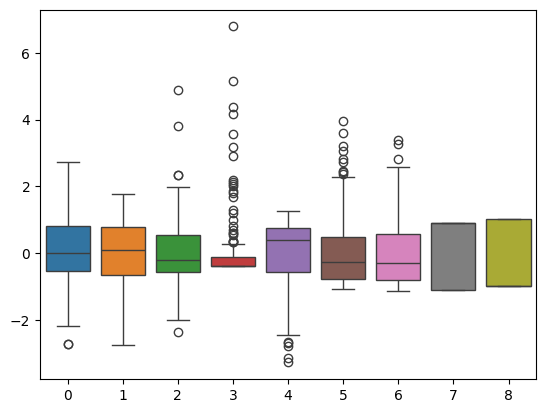

In [48]:
sns.boxplot(data=X_train_scaled)


<Axes: >

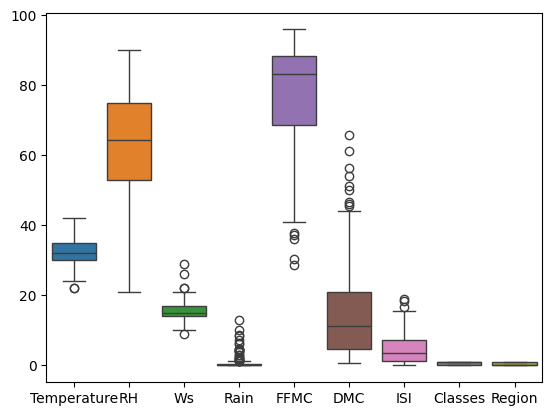

In [49]:
sns.boxplot(data=X_train)

<Axes: >

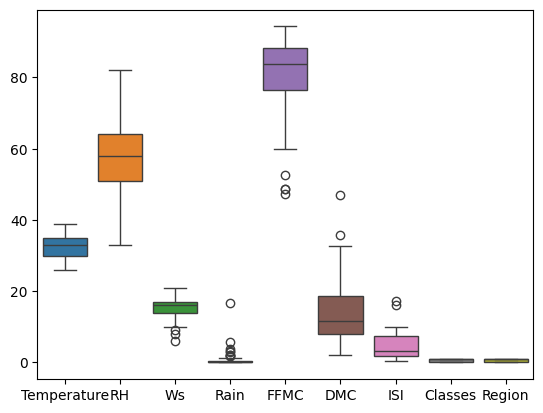

In [50]:
sns.boxplot(X_test)

In [51]:
from sklearn.linear_model import LinearRegression,ElasticNet,ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error

net=ElasticNetCV(cv=5,l1_ratio=[.1,.2,.3,.5,.7,.9,.95,.99,1],alphas=100,n_jobs=-1,)
net.fit(X_train_scaled,y_train)
y_pred=net.predict(X_test_scaled)
print(f'The alpha value selected by net CV is {net.alpha_}')
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"The mean squared error is {mse}")
print(f'The r2 score is {r2}')

The alpha value selected by net CV is 0.04042896919789233
The mean squared error is 0.7364863751404725
The r2 score is 0.9816800393903456


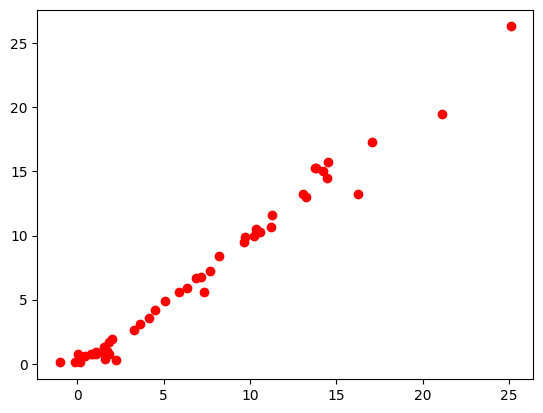

In [52]:
plt.scatter(y_pred, y_test,c='r')

In [53]:
X_train['Rain'].unique()

array([ 0. ,  0.4,  0.2,  0.1,  1.3, 13.1,  4.7,  0.7,  1.8,  1.4,  0.3,
        6.5,  6. ,  0.6,  0.9,  2.9,  0.5,  2.2,  0.8,  8.3,  3.1,  2.5,
        1.2,  2. ,  1.1,  4.6,  4.4,  3.8,  1.7, 10.1,  4.5,  1. ,  7.2,
        8.7,  4.1,  4. ])

In [54]:
import pickle 
pickle.dump(net,open('net-cv.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))

In [56]:
net=pickle.load(open('net-cv.pkl','rb'))

In [57]:
X_train.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes',
       'Region'],
      dtype='str')